# rPDHG benchmark visualizations

Plots produced from `experiments/<run-dir>/*.json`.
Each cell is self-contained; missing fields trigger a printed skip rather than an error so the notebook stays runnable on partial logs.

In [4]:
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd

log_dir = Path("../experiments/32 epoch_length")
DROP_SOLVERS = {"ReBa2.0","ReBa3.0","ReBa4.0"}
all_data = []
for file_path in log_dir.glob("*.json"):
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    if data.get("solver", {}).get("name") in DROP_SOLVERS:
        continue
    all_data.append(data)

df = pd.json_normalize(all_data)

if 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)

print(f"Successfully read {len(df)} experiment runs.")

df['problem_type'] = df.get('problem.dotmark_type')

restart_col = 'solver.restart_check'
runtime_col = 'metrics.runtime_seconds'
iter_col    = 'metrics.iterations'

if 'metrics.status' in df.columns:
    print(f"Not completed: {len(df[df['metrics.status'] != 'completed'])}")

# ---------- derived helpers shared by all plots below ----------

def _diag_key(name):
    """Parse trailing integer from solver names like 'diagnostic25'."""
    if not isinstance(name, str):
        return 10**9
    m = re.search(r"(\d+)$", name)
    return int(m.group(1)) if m else 10**9

if 'solver.name' in df.columns and not df.empty:
    df['solver_order'] = df['solver.name'].map(_diag_key)
    SOLVER_ORDER = (
        df.dropna(subset=['solver.name'])
          .sort_values('solver_order')['solver.name']
          .drop_duplicates()
          .tolist()
    )
else:
    SOLVER_ORDER = []

# Wall-clock per iteration estimate (assumes uniform per-step cost).
if runtime_col in df.columns and iter_col in df.columns:
    df['sec_per_iter'] = df[runtime_col] / df[iter_col].replace(0, np.nan)
else:
    df['sec_per_iter'] = np.nan

def _seq(row, *candidates):
    """Return first list-valued field among candidates; else []."""
    for c in candidates:
        v = row.get(c)
        if isinstance(v, list):
            return v
    return []

def build_long(df_in, value_keys, value_name):
    """Long-format dataframe with one row per (run, diagnostic step)."""
    records = []
    for idx, row in df_in.iterrows():
        seq = _seq(row, *value_keys)
        if not seq:
            continue
        diag_i = int(row.get('solver.diagnostik_i') or 1)
        sec_per_iter = row.get('sec_per_iter')
        for i, v in enumerate(seq):
            step = i * diag_i
            records.append({
                'run_id': idx,
                'step': step,
                'wallclock_s': step * sec_per_iter if pd.notna(sec_per_iter) else np.nan,
                value_name: v,
                'solver.name': row.get('solver.name'),
                'solver_order': row.get('solver_order'),
                'problem.name': row.get('problem.name'),
                'problem_type': row.get('problem_type'),
                'runtime_s': row.get(runtime_col),
            })
    return pd.DataFrame.from_records(records)

df_completed = (
    df[df['metrics.status'] == 'completed'].copy()
    if 'metrics.status' in df.columns else df.copy()
)
print(f"Completed runs: {len(df_completed)}")
print(f"Solver order: {SOLVER_ORDER}")


Successfully read 900 experiment runs.
Not completed: 0
Completed runs: 900
Solver order: ['min_epo100', 'min_epo300']


In [6]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

DIAGRAM_DIR = Path("../diagrams")
DIAGRAM_DIR.mkdir(exist_ok=True)

def apply_paper_style():
    """Re-apply our paper style. Call at the top of every plot cell because
    sns.set_theme() resets rcParams and other cells may reset the style too."""
    sns.set_theme(style='ticks', context='paper', font_scale=1.1)
    mpl.rcParams['font.family'] = 'serif'
    mpl.rcParams['font.serif'] = ['Times New Roman'] + mpl.rcParams['font.serif']
    mpl.rcParams['figure.facecolor'] = 'white'
    mpl.rcParams['axes.facecolor'] = 'white'
    mpl.rcParams['savefig.facecolor'] = 'white'

apply_paper_style()
palette = sns.color_palette("colorblind")
RED = palette[3]    # vermillion red used in the 5-solver comparison
BROWN = palette[5]  # brown that appears once a 6th solver is added
# Assign colors by position in SOLVER_ORDER, but swap the brown for the red
# so the figure keeps the same look as the original 5-solver comparison.
SOLVER_PALETTE = {}
for i, s in enumerate(SOLVER_ORDER):
    c = palette[i % len(palette)]
    if c == BROWN:
        c = RED
    SOLVER_PALETTE[s] = c

def save_fig(fig_or_grid, name):
    """Save both PNG and PDF into ../diagrams/."""
    obj = fig_or_grid.fig if hasattr(fig_or_grid, 'fig') else fig_or_grid
    obj.savefig(DIAGRAM_DIR / f"{name}.png", dpi=300, bbox_inches='tight')
    obj.savefig(DIAGRAM_DIR / f"{name}.pdf", bbox_inches='tight')
    print(f"Saved diagrams/{name}.png and diagrams/{name}.pdf")

## Runtime per solver, per DOTmark class

Bar = mean, whiskers = 50% percentile interval (interquartile), dots = individual runs. Log y so the slow `diagnostic1` runs do not flatten the rest.

Saved diagrams/transportation_runtime_results.png and diagrams/transportation_runtime_results.pdf


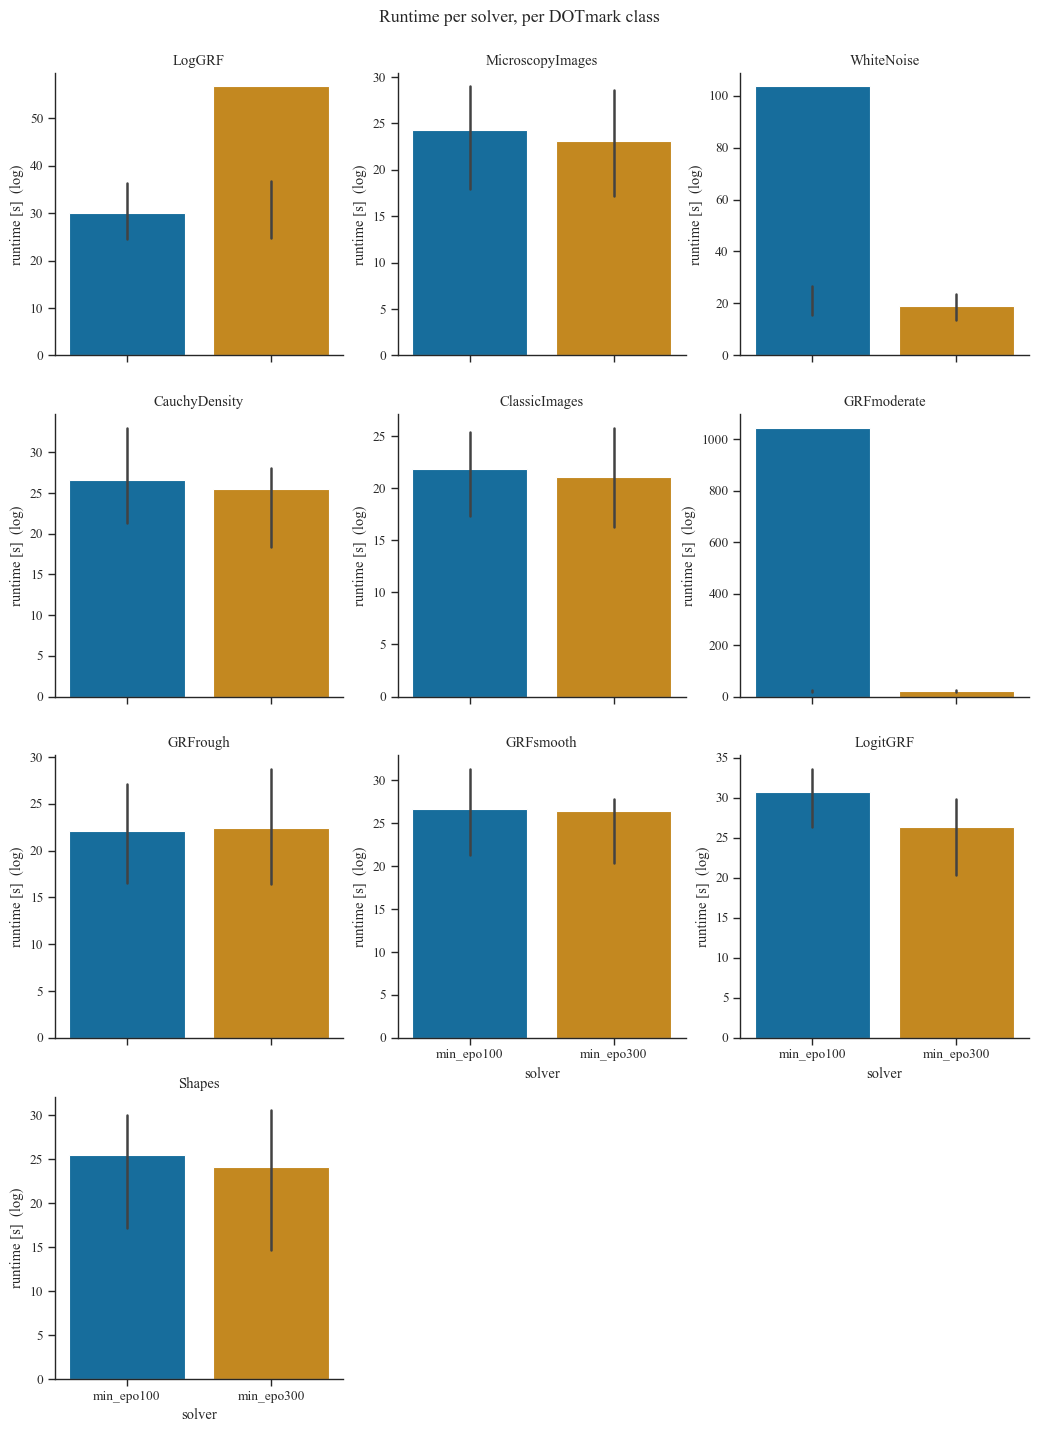

In [7]:
apply_paper_style()

runtime_graph = sns.catplot(
    data=df_completed,
    y=runtime_col,
    x='solver.name',
    order=SOLVER_ORDER,
    hue='solver.name',
    hue_order=SOLVER_ORDER,
    kind='bar',
    col='problem_type',
    col_wrap=3,
    palette=SOLVER_PALETTE,
    height=3.5,
    aspect=1.0,
    legend=False,
    sharey=False,
    errorbar=('pi', 50),
)

for ax in runtime_graph.axes.flatten():
    ptype = ax.get_title()
    sub = df_completed[df_completed['problem_type'] == ptype]
    if sub.empty:
        continue
    sns.stripplot(
        data=sub, x='solver.name', y=runtime_col,
        order=SOLVER_ORDER, color='black', size=2.5, alpha=0.45,
        ax=ax, jitter=0.18,
    )
    means = sub.groupby('solver.name')[runtime_col].mean().reindex(SOLVER_ORDER)
    for i, s in enumerate(SOLVER_ORDER):
        m = means.get(s)
        if pd.notna(m):
            ax.text(i, m, f" {m:.1f}s", ha='center', va='bottom', fontsize=8)
    ax.set_yscale('log')

runtime_graph.set(xlabel='solver', ylabel='runtime [s]  (log)')
runtime_graph.set_titles(template="{col_name}")
runtime_graph.fig.suptitle("Runtime per solver, per DOTmark class", y=1.02)
save_fig(runtime_graph, "transportation_runtime_results")
plt.show()

## Plot C — duality-gap decay (all diagnostic intervals)

x-axis is wall-clock seconds so curves from different `diagnostik_i` values are commensurate. Restart events show as colored ticks at the top of each panel. The grey dashed line marks the default relative tolerance (`1e-2`).

In [ ]:
apply_paper_style()

gap_long = build_long(
    df_completed,
    value_keys=['sequences.duality_gap', 'sequences.gaps'],
    value_name='gap',
)

if gap_long.empty:
    print("Plot C: no duality-gap sequences found in JSON — skipping.")
else:
    gap_long['gap'] = gap_long['gap'].astype(float)
    first = gap_long.sort_values('step').groupby('run_id')['gap'].transform('first')
    gap_long = gap_long[first > 0].copy()
    gap_long['normalized_gap'] = gap_long['gap'] / first[first > 0]

    g = sns.relplot(
        data=gap_long,
        x='wallclock_s',
        y='normalized_gap',
        col='problem_type',
        hue='solver.name',
        hue_order=SOLVER_ORDER,
        palette=SOLVER_PALETTE,
        kind='line',
        units='run_id',
        estimator=None,
        col_wrap=3,
        height=3.5,
        aspect=1.2,
        facet_kws={'sharex': False, 'sharey': True},
        alpha=0.55,
        linewidth=0.9,
    )
    g.set(yscale='log')
    g.set_titles("{col_name}")
    g.set_axis_labels("Wall-clock time [s]", "Relative duality gap (log)")
    for ax in g.axes.flatten():
        ax.axhline(1e-2, ls='--', lw=0.7, color='grey')

    col_to_ax = {ax.get_title(): ax for ax in g.axes.flatten()}
    for idx, row in df_completed.iterrows():
        ris = _seq(row, 'sequences.restart_indices')
        if not ris:
            continue
        sec_per_iter = row.get('sec_per_iter')
        if pd.isna(sec_per_iter):
            continue
        ax = col_to_ax.get(row.get('problem_type'))
        if ax is None:
            continue
        color = SOLVER_PALETTE.get(row.get('solver.name'), 'k')
        for ri in ris:
            ax.plot(ri * sec_per_iter, 1.0, marker='|', markersize=6,
                    color=color, alpha=0.6)

    g.fig.suptitle('Duality-gap decay (adaptive restart)', y=1.02)
    save_fig(g, "transportation_gap_convergence")
    plt.show()

## Plot A — rPDHG vs Gurobi runtime (log–log scatter)

Each marker is one problem instance solved by both rPDHG and Gurobi. Points below the dashed `y = x` line are faster on rPDHG.

In [ ]:
apply_paper_style()

if 'solver.name' not in df.columns:
    print("Plot A: no solver.name column — skipping.")
else:
    gurobi_mask = df['solver.name'].str.contains('gurobi', case=False, na=False)
    df_gurobi = df[gurobi_mask].copy()
    df_rpdhg = df[~gurobi_mask].copy()
    if 'metrics.status' in df.columns:
        df_rpdhg = df_rpdhg[df_rpdhg['metrics.status'] == 'completed']

    if df_gurobi.empty or df_rpdhg.empty:
        print("Plot A: need at least one Gurobi and one rPDHG run — skipping.")
    else:
        g_runtime = (df_gurobi.groupby('problem.name')[runtime_col]
                              .median()
                              .rename('gurobi_seconds'))
        merged = df_rpdhg.merge(g_runtime, on='problem.name', how='inner')
        if merged.empty:
            print("Plot A: no matching problem.name between rPDHG and Gurobi — skipping.")
        else:
            fig, ax = plt.subplots(figsize=(6, 6))
            sns.scatterplot(
                data=merged,
                x='gurobi_seconds',
                y=runtime_col,
                hue='problem_type',
                style='solver.name',
                ax=ax,
                s=40,
                alpha=0.8,
                palette='colorblind',
            )
            lo = max(min(merged['gurobi_seconds'].min(),
                         merged[runtime_col].min()), 1e-2)
            hi = max(merged['gurobi_seconds'].max(), merged[runtime_col].max())
            ax.plot([lo, hi], [lo, hi], ls='--', color='black', lw=0.8, label='y = x')
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel("Gurobi runtime [s]")
            ax.set_ylabel("rPDHG runtime [s]")
            ax.set_title("rPDHG vs Gurobi (log–log)")
            ax.legend(bbox_to_anchor=(1.02, 1.0), loc='upper left', fontsize=8)
            sns.despine(fig=fig)
            save_fig(fig, "rpdhg_vs_gurobi_runtime")
            plt.show()

## Plot B — performance profile (Dolan–Moré)

For each solver, plots the fraction of problems solved within a factor τ of the best-performing solver on that problem. A solver whose curve sits above another at τ = 1 is the most-often-fastest; the curve's asymptote shows on what fraction of problems it ever finishes within τ of the best.

In [ ]:
apply_paper_style()

if 'problem.name' not in df_completed.columns or df_completed['problem.name'].isna().all():
    print("Plot B: missing problem.name column — skipping.")
else:
    pivot = (df_completed.groupby(['problem.name', 'solver.name'])[runtime_col]
                          .median().unstack('solver.name'))
    pivot = pivot.reindex(columns=[s for s in SOLVER_ORDER if s in pivot.columns])
    pivot = pivot.dropna(thresh=2)

    if pivot.empty or pivot.shape[1] < 2:
        print("Plot B: not enough overlap between solvers and problems — skipping.")
    else:
        best = pivot.min(axis=1)
        ratio = pivot.div(best, axis=0)

        tau_max = max(float(ratio.max().max()), 1.5)
        tau_grid = np.logspace(0, np.log10(tau_max), 200)
        fig, ax = plt.subplots(figsize=(7, 4.5))
        for s in pivot.columns:
            r = ratio[s].dropna().values
            if r.size == 0:
                continue
            frac = np.array([np.mean(r <= t) for t in tau_grid])
            ax.plot(tau_grid, frac, label=s, lw=1.5, color=SOLVER_PALETTE.get(s))
        ax.set_xscale('log')
        ax.set_xlabel(r"performance ratio  $\tau$  (log)")
        ax.set_ylabel(r"fraction of problems within $\tau \times$ best")
        ax.set_title("Performance profile (Dolan–Moré, runtime)")
        ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.3)
        ax.legend(title='solver', fontsize=9)
        sns.despine(fig=fig)
        save_fig(fig, "performance_profile")
        plt.show()

## Plot D — iterations spent before / between / after restarts

Stacked bar per (problem class, solver). Shows whether speedups come from a long restart-free warmup, frequent productive restarts, or a long polishing phase after the last restart.

In [ ]:
apply_paper_style()

records = []
for idx, row in df_completed.iterrows():
    ris = _seq(row, 'sequences.restart_indices')
    iters = row.get(iter_col)
    if iters is None or iters == 0:
        continue
    if ris:
        first = ris[0]
        last = ris[-1]
        between = (last - first) / max(len(ris) - 1, 1) if len(ris) > 1 else 0
        after = iters - last
    else:
        first, between, after = iters, 0, 0
    records.append({
        'run_id': idx,
        'solver.name': row.get('solver.name'),
        'problem_type': row.get('problem_type'),
        'before_first': first,
        'mean_between': between,
        'after_last': after,
    })

restart_df = pd.DataFrame(records)
if restart_df.empty:
    print("Plot D: no usable restart data — skipping.")
else:
    agg = (restart_df.groupby(['problem_type', 'solver.name'])
                     [['before_first', 'mean_between', 'after_last']]
                     .mean().reset_index())
    problem_types = sorted(agg['problem_type'].dropna().unique())
    fig, axes = plt.subplots(
        1, len(problem_types),
        figsize=(3.0 * len(problem_types), 4),
        sharey=False, squeeze=False,
    )
    bar_labels = [('before_first', 'before 1st'),
                  ('mean_between', 'mean btw'),
                  ('after_last', 'after last')]
    for ax, ptype in zip(axes.flatten(), problem_types):
        sub = (agg[agg['problem_type'] == ptype]
                  .set_index('solver.name')
                  .reindex(SOLVER_ORDER))
        bottom = np.zeros(len(sub))
        for col, label in bar_labels:
            vals = sub[col].fillna(0).values
            ax.bar(sub.index, vals, bottom=bottom, label=label)
            bottom += vals
        ax.set_title(ptype)
        ax.set_ylabel('iterations')
        ax.tick_params(axis='x', rotation=30)
    axes.flatten()[-1].legend(
        bbox_to_anchor=(1.02, 1.0), loc='upper left', fontsize=8
    )
    fig.suptitle(
        "Restart cadence: iterations spent before / between / after restarts",
        y=1.02,
    )
    fig.tight_layout()
    save_fig(fig, "restart_breakdown")
    plt.show()

## Plot E — primal vs dual residual trajectories

If `rebalance_tau_sigma` is doing its job, the two residuals should track each other in scale. Big persistent gap → ratio test is misfiring.

In [ ]:
apply_paper_style()

primal_long = build_long(
    df_completed,
    value_keys=['sequences.primal_residual', 'sequences.primal_res',
                'sequences.primal_res_seq'],
    value_name='primal_res',
)
dual_long = build_long(
    df_completed,
    value_keys=['sequences.dual_residual', 'sequences.dual_res',
                'sequences.dual_res_seq'],
    value_name='dual_res',
)

if primal_long.empty and dual_long.empty:
    print("Plot E: no residual sequences logged — skipping.")
else:
    if not primal_long.empty:
        primal_long = primal_long.rename(columns={'primal_res': 'value'})
        primal_long['residual_kind'] = 'primal'
    if not dual_long.empty:
        dual_long = dual_long.rename(columns={'dual_res': 'value'})
        dual_long['residual_kind'] = 'dual'
    res_long = pd.concat(
        [d for d in [primal_long, dual_long] if not d.empty],
        ignore_index=True,
    )
    res_long = res_long[res_long['value'] > 0]

    g = sns.relplot(
        data=res_long,
        x='step', y='value',
        col='problem_type', col_wrap=3,
        hue='residual_kind',
        units='run_id', estimator=None,
        kind='line', height=3.5, aspect=1.2,
        facet_kws={'sharex': False, 'sharey': True},
        alpha=0.5, linewidth=0.8,
    )
    g.set(yscale='log')
    g.set_axis_labels("iteration", r"residual  $\|\cdot\|_2$  (log)")
    g.set_titles("{col_name}")
    g.fig.suptitle("Primal vs dual residual trajectories", y=1.02)
    save_fig(g, "residual_trajectories")
    plt.show()

## Plot F — step-size adaptation trace

Tracks $\tau \cdot \sigma$ across iterations. Convergence requires $\tau \sigma \|A\|_2^2 < 1$, which here means $\tau \sigma < 1/(2N)$ — runs that sit just below that line are exploiting the line search aggressively.

**Note:** requires `pdhg_restarted_cu.py` to append `tau` / `sigma` to lists each diagnostic step and pass them through `sequences=` in `write_experiment_run`. The plot will print a clear skip message until that is added.

In [ ]:
apply_paper_style()

tau_long = build_long(
    df_completed,
    value_keys=['sequences.tau', 'sequences.step_tau', 'sequences.tau_seq'],
    value_name='tau',
)
sigma_long = build_long(
    df_completed,
    value_keys=['sequences.sigma', 'sequences.step_sigma', 'sequences.sigma_seq'],
    value_name='sigma',
)

if tau_long.empty or sigma_long.empty:
    print(
        "Plot F: tau/sigma history not present in JSON.\n"
        "  → To enable, append tau/sigma to lists each diagnostic step in\n"
        "    pdhg_restarted_cu.py and pass them through `sequences=` in\n"
        "    write_experiment_run."
    )
else:
    merged = tau_long.merge(
        sigma_long[['run_id', 'step', 'sigma']],
        on=['run_id', 'step'], how='inner',
    )
    merged['product'] = merged['tau'] * merged['sigma']
    g = sns.relplot(
        data=merged, x='step', y='product',
        col='problem_type', col_wrap=3,
        hue='solver.name', hue_order=SOLVER_ORDER,
        palette=SOLVER_PALETTE,
        units='run_id', estimator=None,
        kind='line', height=3.5, aspect=1.2,
        facet_kws={'sharex': False},
        alpha=0.55, linewidth=0.9,
    )
    g.set(yscale='log')
    g.set_axis_labels("iteration", r"$\tau \cdot \sigma$  (log)")
    g.set_titles("{col_name}")
    g.fig.suptitle("Step-size adaptation across iterations", y=1.02)
    save_fig(g, "stepsize_adaptation")
    plt.show()

## Plot G — restart-cadence heatmap

Each row = one run, x = progress through the run (0 → end), color = epoch index (i.e. how many restarts have fired so far). Runs are sorted by problem type so blocks of one DOTmark class are visually grouped.

In [ ]:
apply_paper_style()

focus_solver = 'diagnostic25' if 'diagnostic25' in SOLVER_ORDER else (
    SOLVER_ORDER[0] if SOLVER_ORDER else None
)
if focus_solver is None:
    print("Plot G: no solvers found — skipping.")
else:
    sub = df_completed[df_completed['solver.name'] == focus_solver]
    heat_rows = []
    for idx, row in sub.iterrows():
        ris = _seq(row, 'sequences.restart_indices')
        iters = int(row.get(iter_col) or 0)
        if iters == 0:
            continue
        heat_rows.append({
            'run_id': idx,
            'problem': row.get('problem.name'),
            'problem_type': row.get('problem_type'),
            'iters': iters,
            'restarts': ris,
        })
    if not heat_rows:
        print("Plot G: no restart_indices logged — skipping.")
    else:
        heat_rows.sort(key=lambda r: (r['problem_type'] or '', r['iters']))
        n_bins = 200
        H = np.full((len(heat_rows), n_bins), np.nan)
        for i, r in enumerate(heat_rows):
            bin_edges = np.linspace(0, r['iters'], n_bins + 1)
            cuts = [0] + list(r['restarts']) + [r['iters']]
            epoch_idx = 0
            for j in range(n_bins):
                center = 0.5 * (bin_edges[j] + bin_edges[j + 1])
                while epoch_idx + 1 < len(cuts) and center >= cuts[epoch_idx + 1]:
                    epoch_idx += 1
                H[i, j] = epoch_idx

        fig, ax = plt.subplots(figsize=(9, max(4, len(heat_rows) * 0.12)))
        im = ax.imshow(H, aspect='auto', interpolation='nearest', cmap='viridis')
        ax.set_xlabel("normalized iteration progress")
        ax.set_ylabel(f"runs ({focus_solver}), sorted by problem type")
        ax.set_xticks(np.linspace(0, n_bins - 1, 5))
        ax.set_xticklabels([f"{x:.0%}" for x in np.linspace(0, 1, 5)])
        fig.colorbar(im, ax=ax, label='epoch index')
        last_ptype = None
        for i, r in enumerate(heat_rows):
            if last_ptype is not None and r['problem_type'] != last_ptype:
                ax.axhline(i - 0.5, color='white', lw=0.7)
            last_ptype = r['problem_type']
        fig.suptitle("Restart-cadence heatmap", y=1.02)
        save_fig(fig, "restart_cadence_heatmap")
        plt.show()

# Iteration-based views (hardware-independent)

The figures above are reported in wall-clock seconds. The cells below re-plot the same comparisons against **iteration count**, a hardware-independent metric for comparing solver variants (mirrors of the runtime bar chart, Plot C gap-decay, and Plot B performance profile).

**Caveat:** iterations are *not* equally expensive here. The line-search inner loop in `pdhg_restarted_cu.py` recomputes the step several times per accepted iteration, so a lower iteration count does not always mean less total work — read these alongside the wall-clock figures, not as a replacement. Gurobi is excluded because its simplex/barrier iterations are not commensurable with PDHG iterations.

In [ ]:
apply_paper_style()

# Iteration-count counterpart of the runtime bar chart at the top of the notebook.
iter_graph = sns.catplot(
    data=df_completed,
    y=iter_col,
    x='solver.name',
    order=SOLVER_ORDER,
    hue='solver.name',
    hue_order=SOLVER_ORDER,
    kind='bar',
    col='problem_type',
    col_wrap=3,
    palette=SOLVER_PALETTE,
    height=3.5,
    aspect=1.0,
    legend=False,
    sharey=False,
    errorbar=('pi', 50),
)

for ax in iter_graph.axes.flatten():
    ptype = ax.get_title()
    sub = df_completed[df_completed['problem_type'] == ptype]
    if sub.empty:
        continue
    sns.stripplot(
        data=sub, x='solver.name', y=iter_col,
        order=SOLVER_ORDER, color='black', size=2.5, alpha=0.45,
        ax=ax, jitter=0.18,
    )
    means = sub.groupby('solver.name')[iter_col].mean().reindex(SOLVER_ORDER)
    for i, s in enumerate(SOLVER_ORDER):
        m = means.get(s)
        if pd.notna(m):
            ax.text(i, m, f" {m:.0f}", ha='center', va='bottom', fontsize=8)
    ax.set_yscale('log')

iter_graph.set(xlabel='solver', ylabel='iterations  (log)')
iter_graph.set_titles(template="{col_name}")
iter_graph.fig.suptitle("Iterations per solver, per DOTmark class", y=1.02)
save_fig(iter_graph, "transportation_iterations_results")
plt.show()

In [ ]:
apply_paper_style()

# Same data as Plot C, but x-axis is the iteration index (`step`) instead of
# wall-clock seconds, so curves are commensurable across hardware.
gap_long = build_long(
    df_completed,
    value_keys=['sequences.duality_gap', 'sequences.gaps'],
    value_name='gap',
)

if gap_long.empty:
    print("Gap-vs-iteration: no duality-gap sequences found in JSON — skipping.")
else:
    gap_long['gap'] = gap_long['gap'].astype(float)
    first = gap_long.sort_values('step').groupby('run_id')['gap'].transform('first')
    gap_long = gap_long[first > 0].copy()
    gap_long['normalized_gap'] = gap_long['gap'] / first[first > 0]

    g = sns.relplot(
        data=gap_long,
        x='step',
        y='normalized_gap',
        col='problem_type',
        hue='solver.name',
        hue_order=SOLVER_ORDER,
        palette=SOLVER_PALETTE,
        kind='line',
        units='run_id',
        estimator=None,
        col_wrap=3,
        height=3.5,
        aspect=1.2,
        facet_kws={'sharex': False, 'sharey': True},
        alpha=0.55,
        linewidth=0.9,
    )
    g.set(yscale='log')
    g.set_titles("{col_name}")
    g.set_axis_labels("Iteration", "Relative duality gap (log)")
    for ax in g.axes.flatten():
        ax.axhline(1e-2, ls='--', lw=0.7, color='grey')

    # Restart events as ticks at the iteration index where they fired.
    col_to_ax = {ax.get_title(): ax for ax in g.axes.flatten()}
    for idx, row in df_completed.iterrows():
        ris = _seq(row, 'sequences.restart_indices')
        if not ris:
            continue
        ax = col_to_ax.get(row.get('problem_type'))
        if ax is None:
            continue
        color = SOLVER_PALETTE.get(row.get('solver.name'), 'k')
        for ri in ris:
            ax.plot(ri, 1.0, marker='|', markersize=6, color=color, alpha=0.6)

    g.fig.suptitle('Duality-gap decay vs iterations (adaptive restart)', y=1.02)
    save_fig(g, "transportation_gap_vs_iterations")
    plt.show()

In [ ]:
apply_paper_style()

# Performance profile (Dolan-Moré) on ITERATIONS instead of runtime.
if 'problem.name' not in df_completed.columns or df_completed['problem.name'].isna().all():
    print("Iteration performance profile: missing problem.name column — skipping.")
else:
    pivot = (df_completed.groupby(['problem.name', 'solver.name'])[iter_col]
                          .median().unstack('solver.name'))
    pivot = pivot.reindex(columns=[s for s in SOLVER_ORDER if s in pivot.columns])
    pivot = pivot.dropna(thresh=2)

    if pivot.empty or pivot.shape[1] < 2:
        print("Iteration performance profile: not enough overlap between solvers and problems — skipping.")
    else:
        best = pivot.min(axis=1)
        ratio = pivot.div(best, axis=0)

        tau_max = max(float(ratio.max().max()), 1.5)
        tau_grid = np.logspace(0, np.log10(tau_max), 200)
        fig, ax = plt.subplots(figsize=(7, 4.5))
        for s in pivot.columns:
            r = ratio[s].dropna().values
            if r.size == 0:
                continue
            frac = np.array([np.mean(r <= t) for t in tau_grid])
            ax.plot(tau_grid, frac, label=s, lw=1.5, color=SOLVER_PALETTE.get(s))
        ax.set_xscale('log')
        ax.set_xlabel(r"iteration ratio  $\tau$  (log)")
        ax.set_ylabel(r"fraction of problems within $\tau \times$ best")
        ax.set_title("Performance profile (Dolan–Moré, iterations)")
        ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.3)
        ax.legend(title='solver', fontsize=9)
        sns.despine(fig=fig)
        save_fig(fig, "performance_profile_iterations")
        plt.show()